# **01 — Exploratory Data Analysis**

## 1. Clone repo and set up imports

In [ ]:
REPO_URL = "https://github.com/DhairyaDave08/Sentiment-Analysis"
REPO_DIR = "Sentiment-analysis"

import os

if REPO_URL and not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
elif not REPO_URL:
    print("Set REPO_URL above, then re-run this cell.")
else:
    print(f"{REPO_DIR} already exists locally, skipping clone.")

Cloning into 'Sentiment-analysis'...
remote: Enumerating objects: 40, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 40 (delta 12), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (40/40), 13.03 KiB | 13.03 MiB/s, done.
Resolving deltas: 100% (12/12), done.


In [ ]:
import sys
sys.path.append(os.path.abspath(REPO_DIR))
from src.preprocessing.clean_text import clean_text
from src.preprocessing.tokenize import process

print(clean_text("@user check this out! https://example.com #GreatDay soooo happy!!"))

check this out greatday soooo happy


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## 2. Install and load dataset via kagglehub

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
COLUMN_NAMES = ["target", "ids", "date", "flag", "user", "text"]

file_path = "training.1600000.processed.noemoticon.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "kazanova/sentiment140",
    file_path,
    pandas_kwargs={
        "encoding": "latin-1",
        "header": None,
        "names": COLUMN_NAMES,
    },
)

print(df.shape)
df.head()

/tmp/ipykernel_4182/2641858741.py:7: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 80.9M/80.9M [00:00<00:00, 156MB/s]

Extracting zip of training.1600000.processed.noemoticon.csv...


(1600000, 6)


,target,ids,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [ ]:
df["target"].value_counts()

,count
target,
0,800000
4,800000


## 3. Class balance

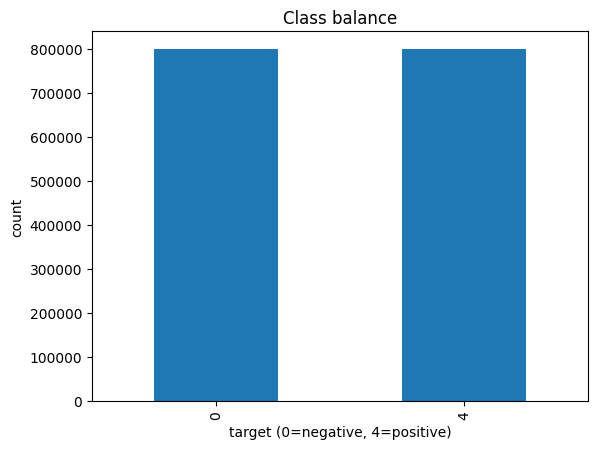

In [ ]:
import matplotlib.pyplot as plt
df["target"].value_counts().plot(kind="bar", title="Class balance")
plt.xlabel("target (0=negative, 4=positive)")
plt.ylabel("count")
plt.show()

## 4. Tweet length distribution

In [ ]:
df["char_length"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().apply(len)
df[["char_length", "word_count"]].describe()

,char_length,word_count
count,1.600000e+06,1.600000e+06
mean,7.409011e+01,1.317615e+01
std,3.644114e+01,6.957978e+00
min,6.000000e+00,1.000000e+00
25%,4.400000e+01,7.000000e+00
50%,6.900000e+01,1.200000e+01
75%,1.040000e+02,1.900000e+01
max,3.740000e+02,6.400000e+01


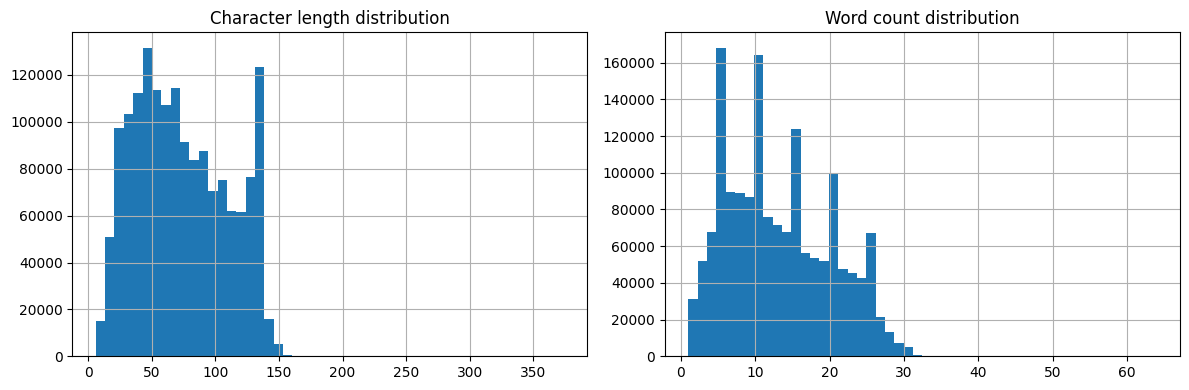

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["char_length"].hist(bins=50, ax=axes[0])
axes[0].set_title("Character length distribution")
df["word_count"].hist(bins=50, ax=axes[1])
axes[1].set_title("Word count distribution")
plt.tight_layout()
plt.show()

## 5. Sample cleaning + tokenization on a subset

In [ ]:
sample = df.sample(n=5000, random_state=42).copy()
sample["cleaned"] = sample["text"].apply(clean_text)
sample["processed"] = sample["cleaned"].apply(process)
sample[["text", "cleaned", "processed"]].head(10)

,text,cleaned,processed
541200,@chrishasboobs AHHH I HOPE YOUR OK!!!,ahhh i hope your ok,ahhh hope ok
750,"@misstoriblack cool , i have no tweet apps fo...",cool i have no tweet apps for my razr,cool tweet app razr
766711,@TiannaChaos i know just family drama. its la...,i know just family drama its lame hey next tim...,know famili drama lame hey next time u hang ki...
285055,School email won't open and I have geography ...,school email won t open and i have geography s...,school email open geographi stuff revis stupid...
705995,upper airways problem,upper airways problem,upper airway problem
379611,Going to miss Pastor's sermon on Faith...,going to miss pastor s sermon on faith,go miss pastor sermon faith
1189018,on lunch....dj should come eat with me,on lunch dj should come eat with me,lunch dj come eat
667030,@piginthepoke oh why are you feeling like that?,oh why are you feeling like that,oh feel like
93541,gahh noo!peyton needs to live!this is horrible,gahh noo peyton needs to live this is horrible,gahh noo peyton need live horribl
1097326,@mrstessyman thank you glad you like it! There...,thank you glad you like it there is a product ...,thank glad like product review bit site enjoy ...


In [ ]:
from collections import Counter

def top_words(texts, n=20):
    counter = Counter()
    for t in texts:
        counter.update(t.split())
    return counter.most_common(n)

pos_words = top_words(sample.loc[sample["target"] == 4, "processed"])
neg_words = top_words(sample.loc[sample["target"] == 0, "processed"])

print("Top positive words:", pos_words)
print()
print("Top negative words:", neg_words)

Top positive words: [('good', 212), ('go', 175), ('thank', 166), ('day', 166), ('love', 164), ('get', 154), ('quot', 150), ('lol', 137), ('like', 127), ('time', 109), ('know', 107), ('work', 106), ('got', 100), ('one', 96), ('follow', 96), ('today', 95), ('u', 95), ('see', 94), ('amp', 81), ('great', 79)]

Top negative words: [('go', 266), ('get', 211), ('day', 173), ('work', 172), ('miss', 163), ('like', 129), ('still', 125), ('today', 124), ('want', 123), ('quot', 111), ('feel', 107), ('back', 104), ('realli', 103), ('need', 100), ('good', 95), ('time', 94), ('got', 94), ('sad', 92), ('home', 88), ('wish', 87)]


In [ ]:
df["cleaned"] = df["text"].apply(clean_text)
df["processed"] = df["cleaned"].apply(process)
processed_df = df[["target", "processed"]].copy()

import os
os.makedirs("data/processed", exist_ok=True)

output_path = "data/processed/processed_tweets.csv"
processed_df.to_csv(output_path, index=False)

print(f"Saved {len(processed_df)} rows to {output_path}")
processed_df.head()
from google.colab import files
files.download(output_path)

Saved 1600000 rows to data/processed/processed_tweets.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>